# Ensemble learning
methods help improve the accuracy of classification and regression models.
The [Random Forest algorithm](https://www.simplilearn.com/tutorials/machine-learning-tutorial/random-forest-algorithm) is an example of ensemble learning.

# Bagging
also known as **Bootstrap aggregating**, is an ensemble learning technique that helps to improve the **performance and accuracy** of machine learning algorithms. It is used to deal with **bias-variance** trade-offs and reduces the variance of a prediction model. Bagging avoids overfitting of data and is used for both regression and classification models, specifically for decision tree algorithms.
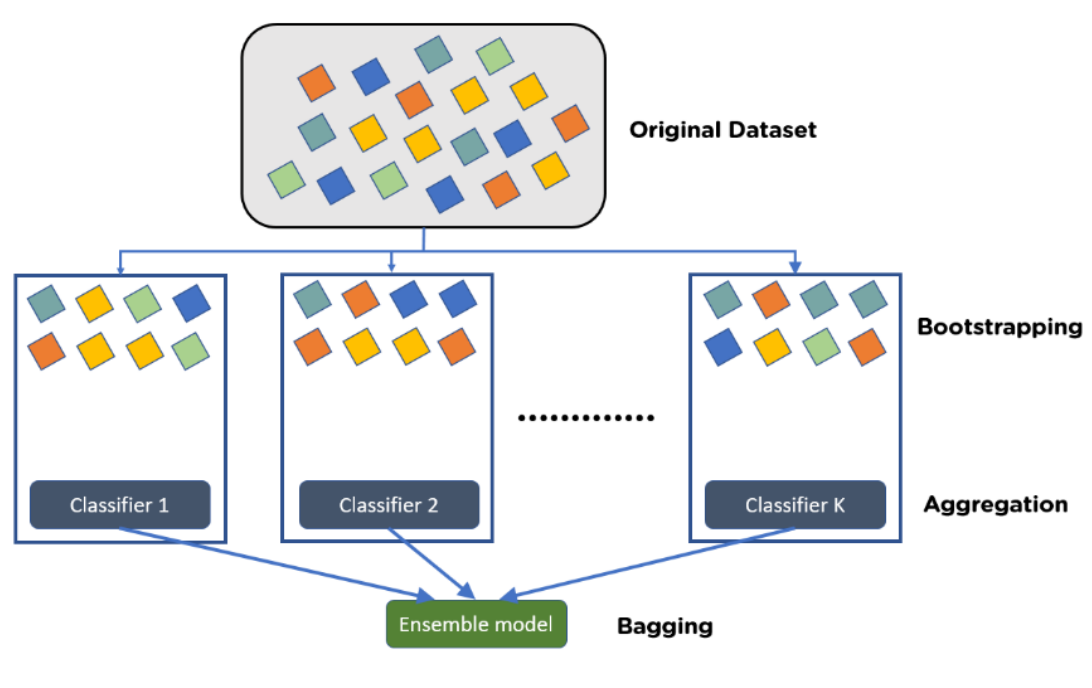

# Bootstrapping
the method of randomly creating samples of data out of a population with replacement to estimate a population parameter.
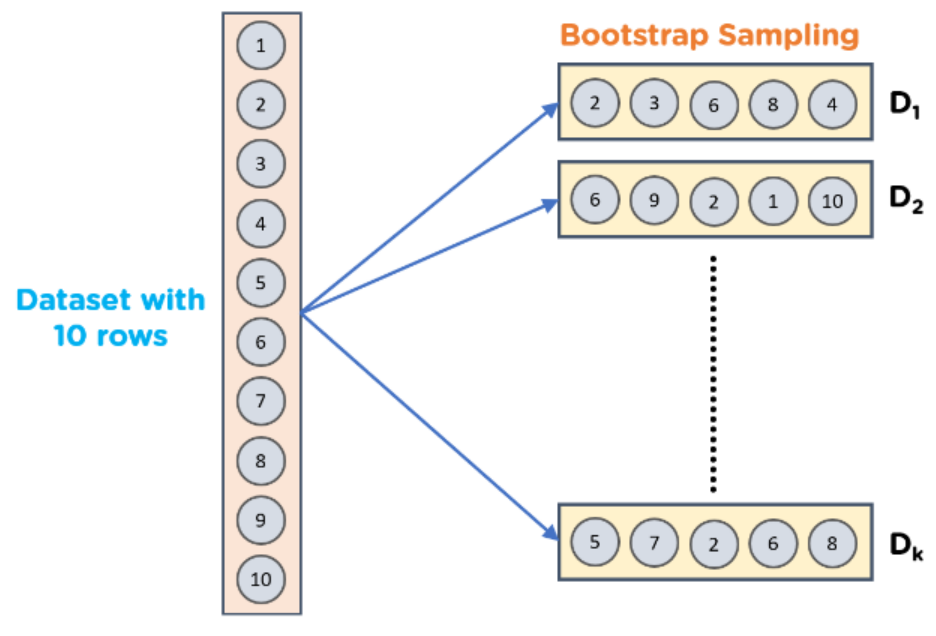

In [1]:
import pandas as pd

# Pima Indians Diabetes datasets
#6 Number of times pregnant

#148 Plasma glucose concentration a 2 hours in an oral glucose tolerance test

#72
Diastolic blood pressure (mm Hg)

#35
Triceps skin fold thickness (mm)

#0
2-Hour serum insulin (mu U/ml)

#33.6
Body mass index (weight in kg/(height in m)^2)

#0.627
Diabetes pedigree function

#50
Age (years)

#1
Class variable (0 or 1) 268 of 768 are 1, the others are 0

In [2]:
df = pd.read_csv('pima-indians-diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# check if any column have any null
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
# tell the basic statiscs of all the features
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# check if there is any imbalance into the dataset
df.Outcome.value_counts()

0    500
1    268
Name: Outcome, dtype: int64

In [6]:
# input dataset
X = df.drop(['Outcome'],axis='columns')
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [7]:
y = df.Outcome

In [8]:
# target dataset
df.Outcome.value_counts()

0    500
1    268
Name: Outcome, dtype: int64

In [9]:
268/500

0.536

In [10]:
# now, let do the scaling since the dataset values are not proper
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# Split the dataset into training and testing ones.
# stratify the input values, to correct the imbalance
# random_state allows the reproducibility, to get the same xtrain & ytrain
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.25,stratify=y,random_state=10)

In [13]:
X_train.shape

(576, 8)

In [14]:
X_test.shape

(192, 8)

In [15]:
y_train.value_counts()

0    375
1    201
Name: Outcome, dtype: int64

In [16]:
201/375

0.536

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

In [18]:
#Load the model and train(fit) it with the training data
decision_tree = DecisionTreeClassifier(random_state=10) # unstable classifier
decision_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=10)

In [19]:
X.shape

(768, 8)

In [20]:
y.shape

(768,)

In [21]:
# this is numpy array
scores = cross_val_score(DecisionTreeClassifier(), X, y, cv=5)
scores.mean()

0.708454290807232

In [23]:
#Get predictions from the trained model and get the training and testing accuracy.
y_pred = decision_tree.predict(X_test)
# y_pred

In [30]:
from sklearn.ensemble import BaggingClassifier

bag_model =BaggingClassifier(
    base_estimator=DecisionTreeClassifier(),
    n_estimators=100,
    oob_score=True,
    max_samples=0.8,
    random_state=0
)
bag_model.fit(X_train, y_train)
bag_model.oob_score_

C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


0.7534722222222222

In [32]:
bag_model.score(X_test, y_test)

0.7760416666666666

In [35]:
bag_model =BaggingClassifier(
    base_estimator=DecisionTreeClassifier(),
    n_estimators=100,
    oob_score=True,
    max_samples=0.8,
    random_state=0
)
score = cross_val_score(bag_model, X, y, cv=5)
score.mean()

C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


0.7578728461081402

In [36]:
from sklearn.ensemble import RandomForestClassifier

score = cross_val_score(RandomForestClassifier(), X, y, cv=5)
score.mean()

0.7722179781003311